In [1]:
import torch
import numpy as np
from training import train
from data_utils import make_dataset, load_dataset, fit_dset_to_m, make_grid_dataset
from controls import LQR
from tasks import stabilize_cartpole
from plotting import plot_trajectories, plot_experiment_new
from models import save_model, load_model
from experiments import save_experiment, load_experiment
import params
from IPython.display import HTML
from copy import deepcopy
import matplotlib.pyplot as plt
import seaborn as sns

######################
### DISPLAY CONFIG ###
######################
for name, values in vars(params).items():
    print(name, values)

torch.set_default_device("cuda")
#torch.set_default_device("cpu")

%load_ext autoreload
%autoreload 2

/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


__name__ params
__doc__ None
__package__ 
__loader__ <_frozen_importlib_external.SourceFileLoader object at 0x7ff23be29310>
__spec__ ModuleSpec(name='params', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7ff23be29310>, origin='/home1/lutkus/latent_space/cartpole_lyapunov/params.py')
__file__ /home1/lutkus/latent_space/cartpole_lyapunov/params.py
__cached__ /home1/lutkus/latent_space/cartpole_lyapunov/__pycache__/params.cpython-313.pyc
__builtins__ {'__name__': 'builtins', '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.", '__package__': '', '__loader__': <class '_frozen_impor

In [2]:
################################
### Load or Generate Dataset ###
################################

#data = make_dataset(save=True, fname=params.dataset, render_mode=None, expert_controller=False)
#data = make_grid_dataset(params.grid_x_ranges, params.grid_u_ranges, params.grid_n_per_axis) # UNCOMMENT THIS TO MAKE DATASET
data = load_dataset(fname=params.dataset)
X, U, Xtest, Utest = data

/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/torch/utils/_device.py:104: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


original state:
 [0.05]
n_combinations 4
n_params 1
{'ae': [('cvar_eps=0.0', []), ('cvar_eps=0.01', []), ('cvar_eps=0.1', []), ('cvar_eps=0.2', [])], 'fdyn': [('cvar_eps=0.0', []), ('cvar_eps=0.01', []), ('cvar_eps=0.1', []), ('cvar_eps=0.2', [])], 'ae_opt': [('cvar_eps=0.0', []), ('cvar_eps=0.01', []), ('cvar_eps=0.1', []), ('cvar_eps=0.2', [])], 'fdyn_opt': [('cvar_eps=0.0', []), ('cvar_eps=0.01', []), ('cvar_eps=0.1', []), ('cvar_eps=0.2', [])], 'ae_list': [('cvar_eps=0.0', []), ('cvar_eps=0.01', []), ('cvar_eps=0.1', []), ('cvar_eps=0.2', [])], 'fdyn_list': [('cvar_eps=0.0', []), ('cvar_eps=0.01', []), ('cvar_eps=0.1', []), ('cvar_eps=0.2', [])], 'rewards': [('cvar_eps=0.0', []), ('cvar_eps=0.01', []), ('cvar_eps=0.1', []), ('cvar_eps=0.2', [])], 'completion_rate': [('cvar_eps=0.0', []), ('cvar_eps=0.01', []), ('cvar_eps=0.1', []), ('cvar_eps=0.2', [])], 'gamma': [('cvar_eps=0.0', []), ('cvar_eps=0.01', []), ('cvar_eps=0.1', []), ('cvar_eps=0.2', [])]}
ENCODER


### Layer 0 ###
Not

  1%|          | 1/100 [00:16<27:38, 16.75s/it]

ep 0: train 1.995108962059021    test 29.835426330566406
rec 1.5362337827682495    mstep 0.45887434482574463    jac 0.0
horizon is now 2


  2%|▏         | 2/100 [00:32<25:56, 15.88s/it]

1.8098073
it: 2; avg reward: 1816.3755455736712; completion rate: 0.38; gamma_max: 1.809807300567627
horizon is now 3


...

0.023236813
it: 96; avg reward: 725.023723861846; completion rate: 0.53; gamma_max: 0.02323681302368641


 98%|█████████▊| 98/100 [1:27:07<01:49, 54.76s/it]

0.021900674
it: 98; avg reward: 749.0574091589051; completion rate: 0.59; gamma_max: 0.02190067432820797


100%|██████████| 100/100 [1:29:19<00:00, 53.60s/it]

ep 99: train 2.0288751125335693    test 2.0105085372924805
rec 1.4623827934265137    mstep 0.5664952993392944    jac 0.0


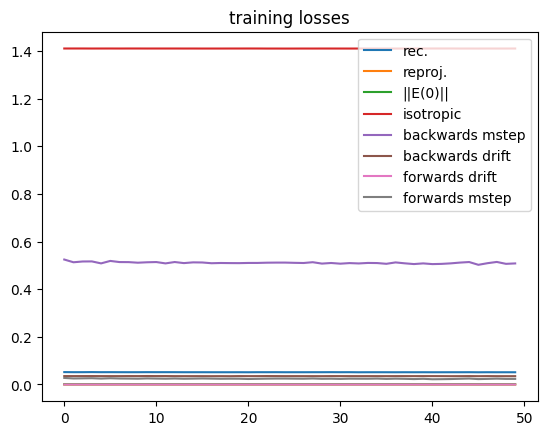

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is <function uniform_ at 0x7f5b59f2b060>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is <function uniform_ at 0x7f5b59f2b060>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is <function zeros_ at 0x7f5b59f2b420>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5

  1%|          | 1/100 [00:16<27:48, 16.86s/it]

ep 0: train 1.4218976497650146    test 10.353946685791016
rec 1.1610280275344849    mstep 0.26086923480033875    jac 0.0
horizon is now 2


  2%|▏         | 2/100 [00:32<26:00, 15.93s/it]

10.574569
it: 2; avg reward: 1913.1542490065951; completion rate: 0.82; gamma_max: 10.574568748474121
horizon is now 3


...

0.4998487
it: 96; avg reward: 1388.1335728472043; completion rate: 0.49; gamma_max: 0.49984869360923767


 98%|█████████▊| 98/100 [1:33:41<02:02, 61.26s/it]

0.50272745
it: 98; avg reward: 1301.4344779930484; completion rate: 0.47; gamma_max: 0.5027274489402771


100%|██████████| 100/100 [1:36:06<00:00, 57.67s/it]

ep 99: train 1.642176628112793    test 1.521262288093567
rec 1.0436125993728638    mstep 0.5985623598098755    jac 0.0


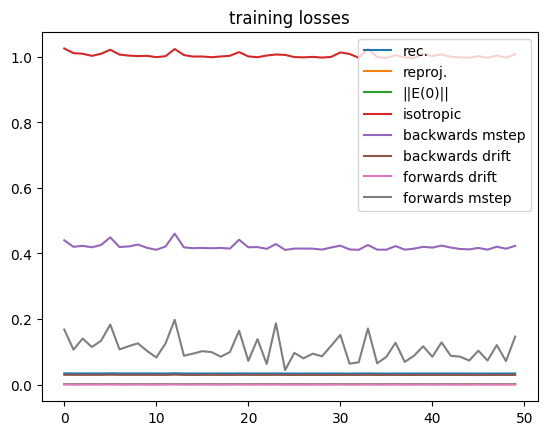

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is <function uniform_ at 0x7f5b59f2b060>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is <function uniform_ at 0x7f5b59f2b060>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is <function zeros_ at 0x7f5b59f2b420>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5

  1%|          | 1/100 [00:16<27:39, 16.77s/it]

ep 0: train 1.297237515449524    test 5.581406116485596
rec 1.1426365375518799    mstep 0.15460169315338135    jac 0.0
horizon is now 2


  2%|▏         | 2/100 [00:31<25:53, 15.86s/it]

5.738609
it: 2; avg reward: 1717.8095041022075; completion rate: 0.65; gamma_max: 5.7386088371276855
horizon is now 3


...

2.2436595
it: 96; avg reward: 2152.459804055784; completion rate: 0.98; gamma_max: 2.243659496307373


 98%|█████████▊| 98/100 [1:35:49<02:04, 62.49s/it]

1.9291054
it: 98; avg reward: 2121.5110955470404; completion rate: 0.96; gamma_max: 1.9291054010391235


100%|██████████| 100/100 [1:38:16<00:00, 58.96s/it]

ep 99: train 0.6137089729309082    test 0.45110785961151123
rec 0.14263916015625    mstep 0.4710697829723358    jac 0.0


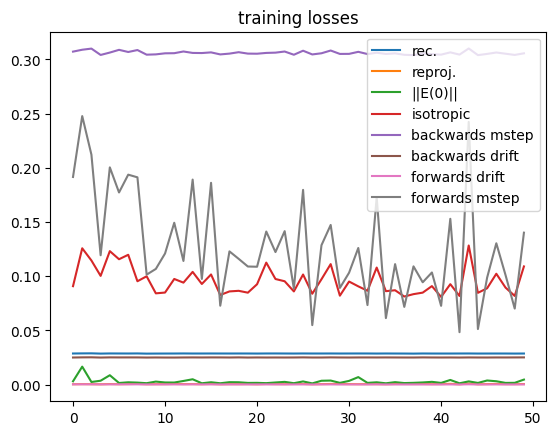

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is <function uniform_ at 0x7f5b59f2b060>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is <function uniform_ at 0x7f5b59f2b060>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5b59f2b6a0>
g bias init is <function zeros_ at 0x7f5b59f2b420>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f5

  1%|          | 1/100 [00:17<28:31, 17.29s/it]

ep 0: train 0.8593442440032959    test 4.88836145401001
rec 0.7651023864746094    mstep 0.09424125403165817    jac 0.0
horizon is now 2


  2%|▏         | 2/100 [00:33<27:18, 16.72s/it]

4.3909445
it: 2; avg reward: 1261.8081493995774; completion rate: 0.6; gamma_max: 4.390944480895996
horizon is now 3


...

1.6759422
it: 96; avg reward: 1690.6414072761745; completion rate: 0.86; gamma_max: 1.6759421825408936


 98%|█████████▊| 98/100 [1:36:52<02:07, 63.94s/it]

1.4293543
it: 98; avg reward: 1629.1465466266218; completion rate: 0.92; gamma_max: 1.4293543100357056


100%|██████████| 100/100 [1:39:25<00:00, 59.66s/it]

ep 99: train 0.4249610900878906    test 0.38399946689605713
rec 0.10503333061933517    mstep 0.3199273943901062    jac 0.0


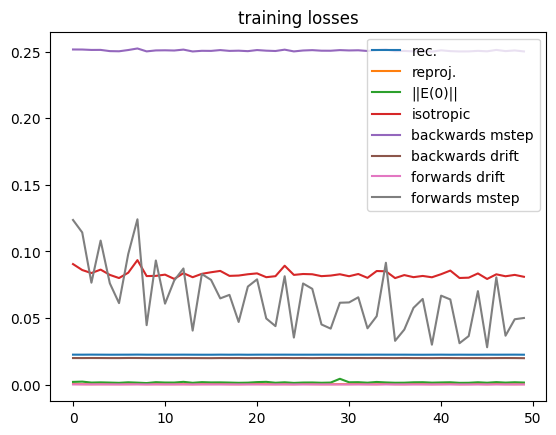

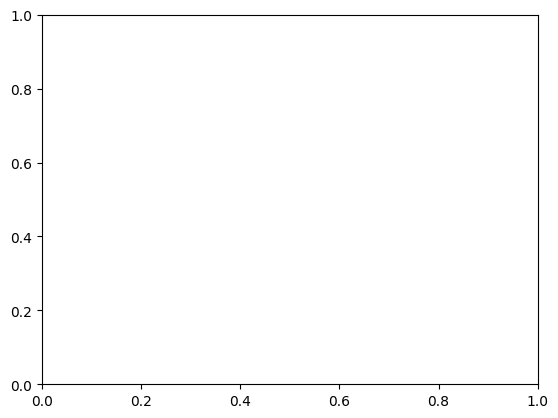

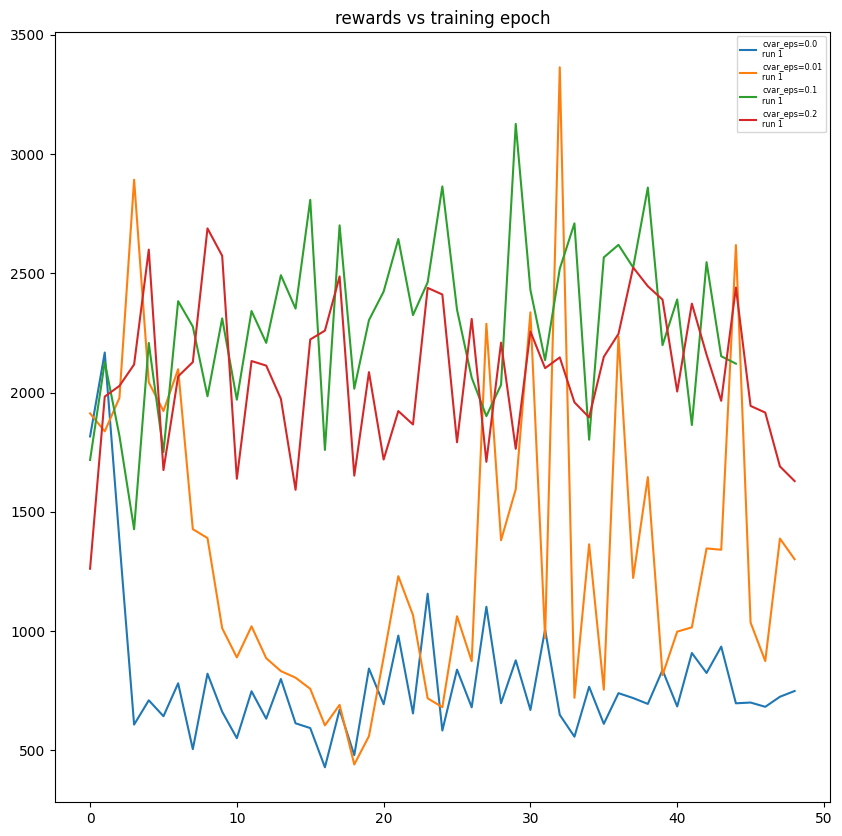

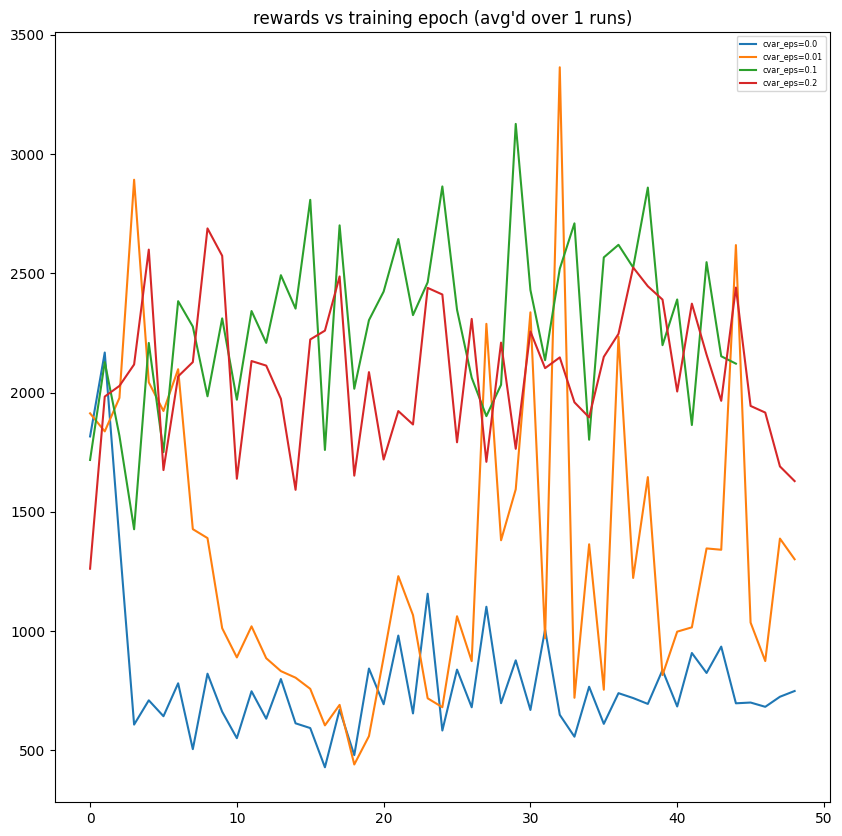

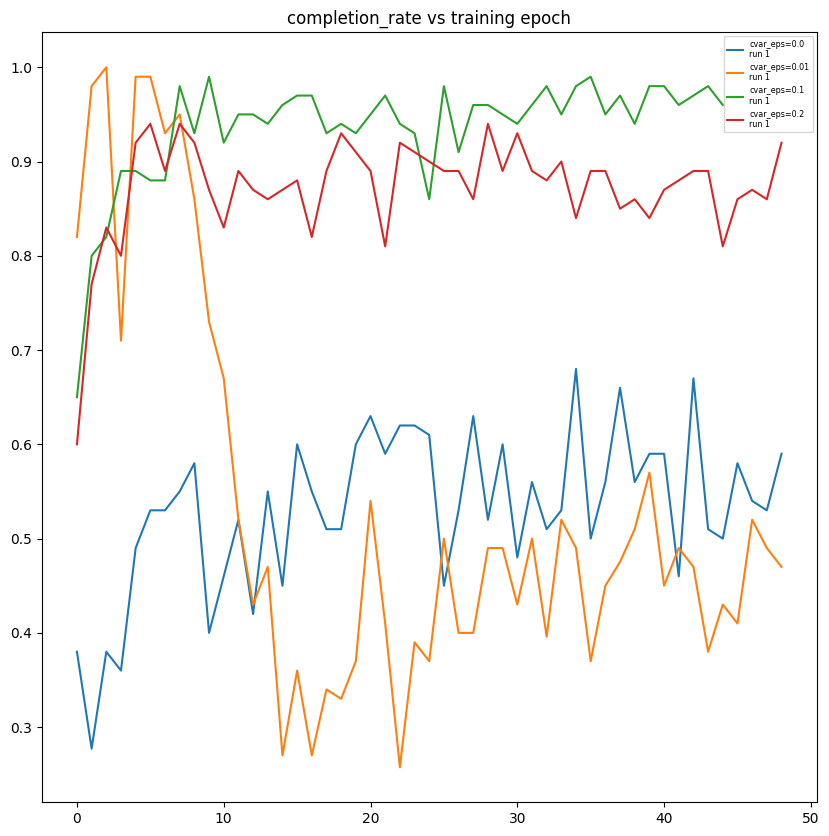

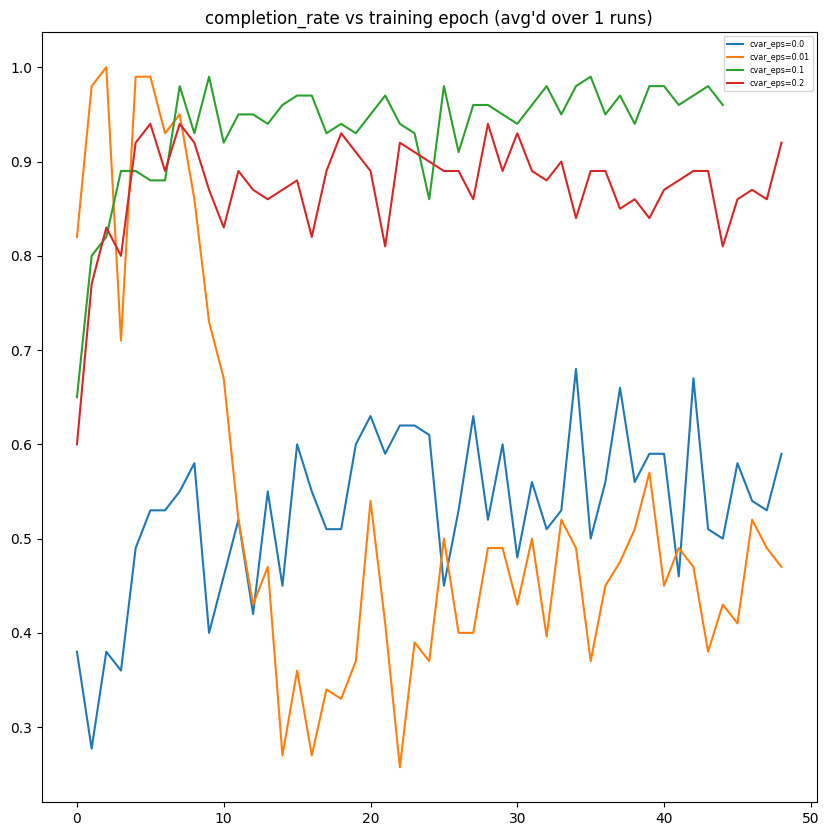

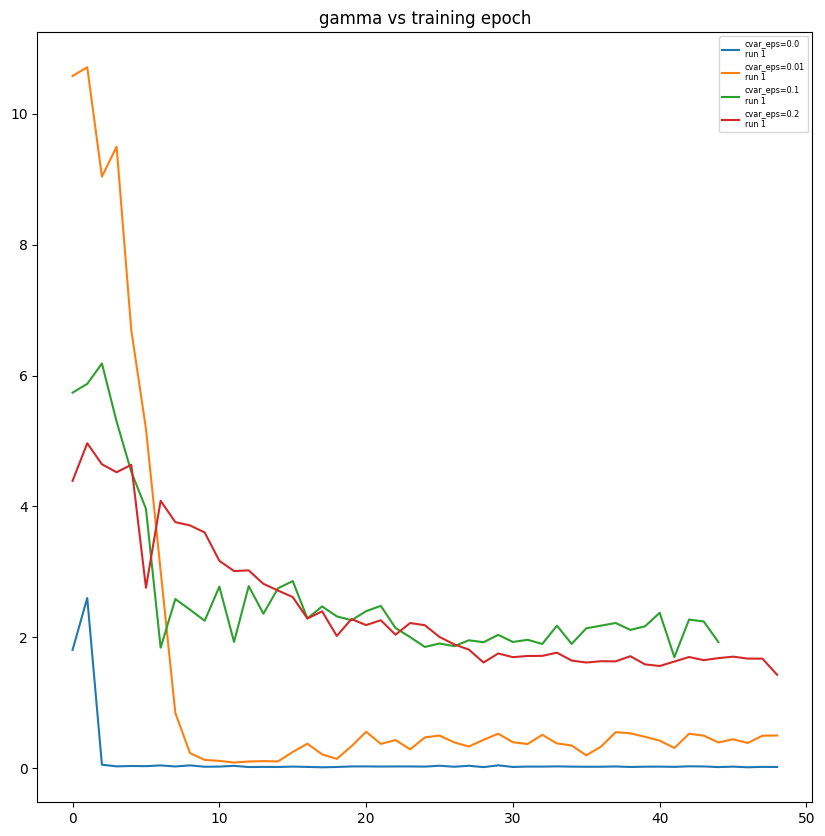

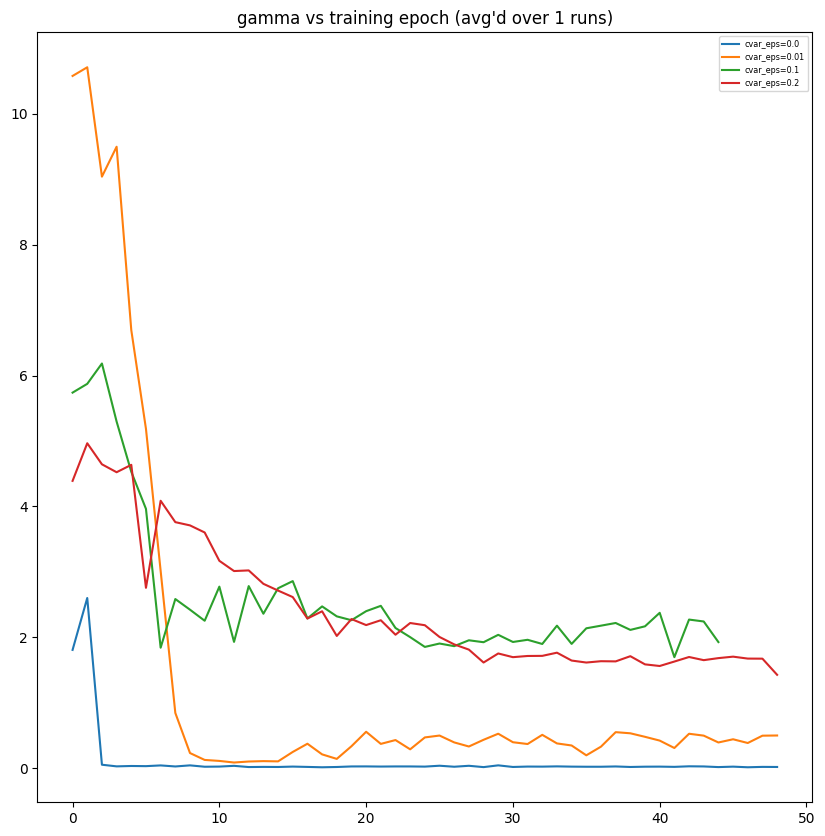

final state
 [0.05]
saving cvar.pkl


In [3]:
#####################################
### Run Experiment to Train Model ###
#####################################

from experiments import run_experiment_new

name = 'cvar'
#spec = {'symbols': [(0,1,2,3), (0, 1, 3), (1, 2, 3), (1, 3)],
#        'ignored': [(), (2,), (0,), (0, 2)]}
spec = {'cvar_eps': [0.0, 0.01, 0.10, 0.20]}
n_runs = [1, 1, 1, 1]
exp=run_experiment_new(data, spec, plot=True, n_runs=n_runs, fname=name, save=True)

In [4]:
#######################
### Save Experiment ###
#######################

save_name = name
save_experiment(save_name, exp)

saving cvar.pkl


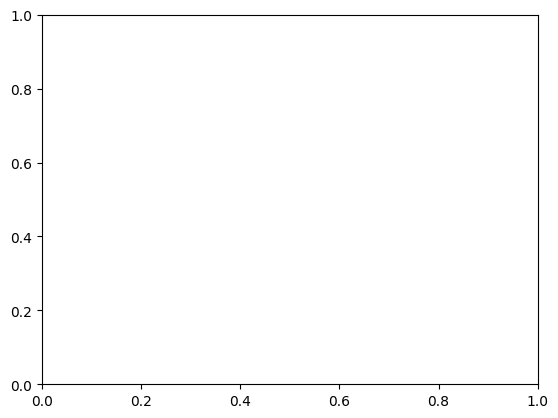

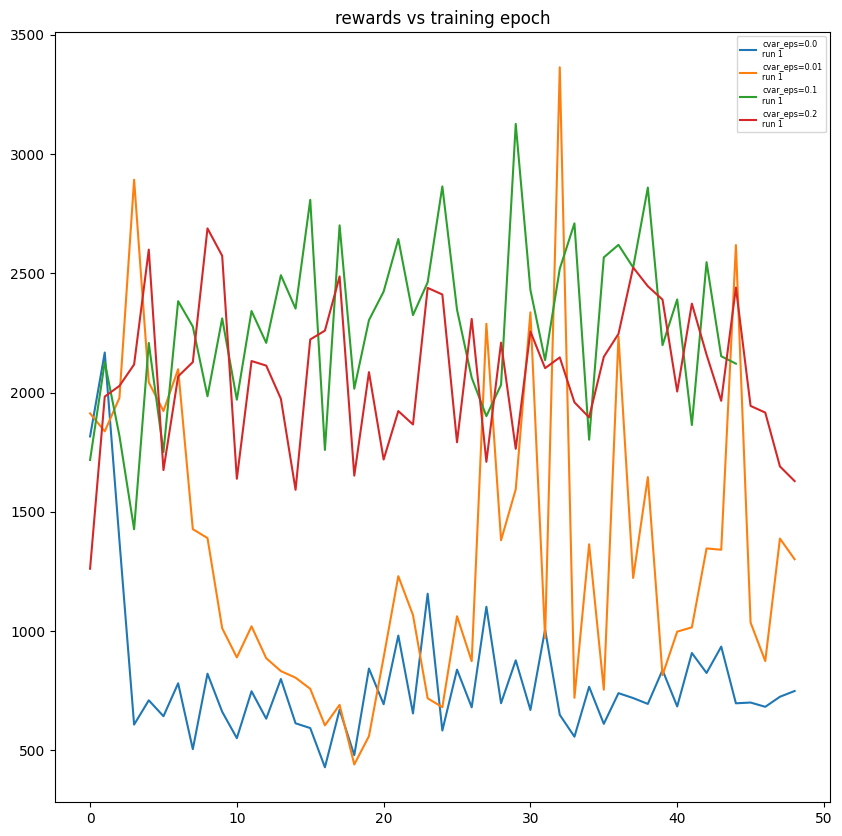

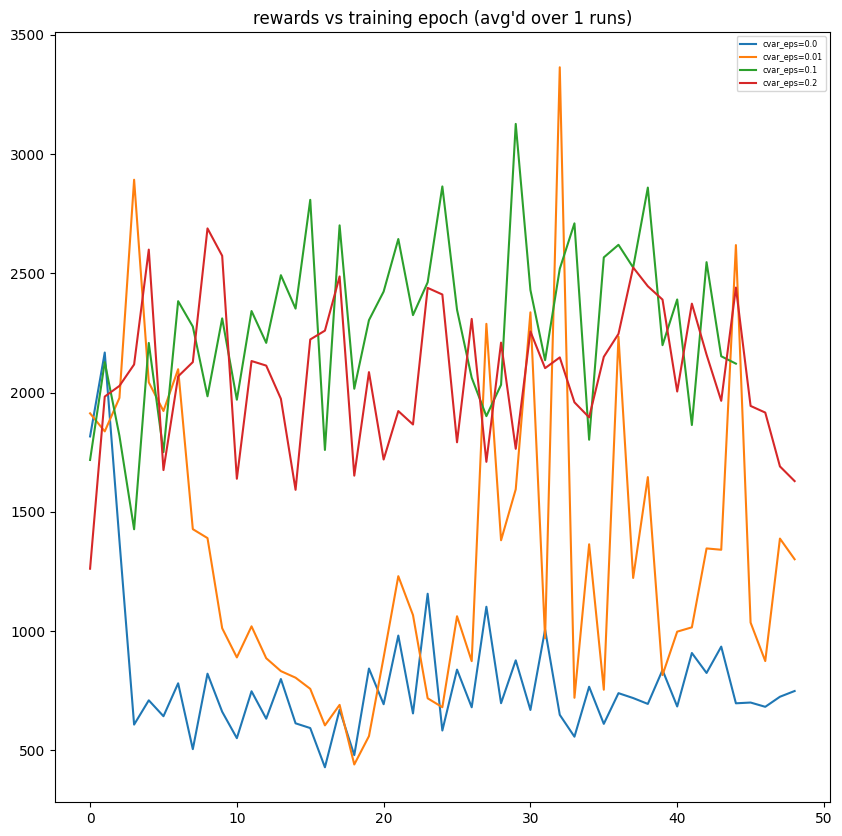

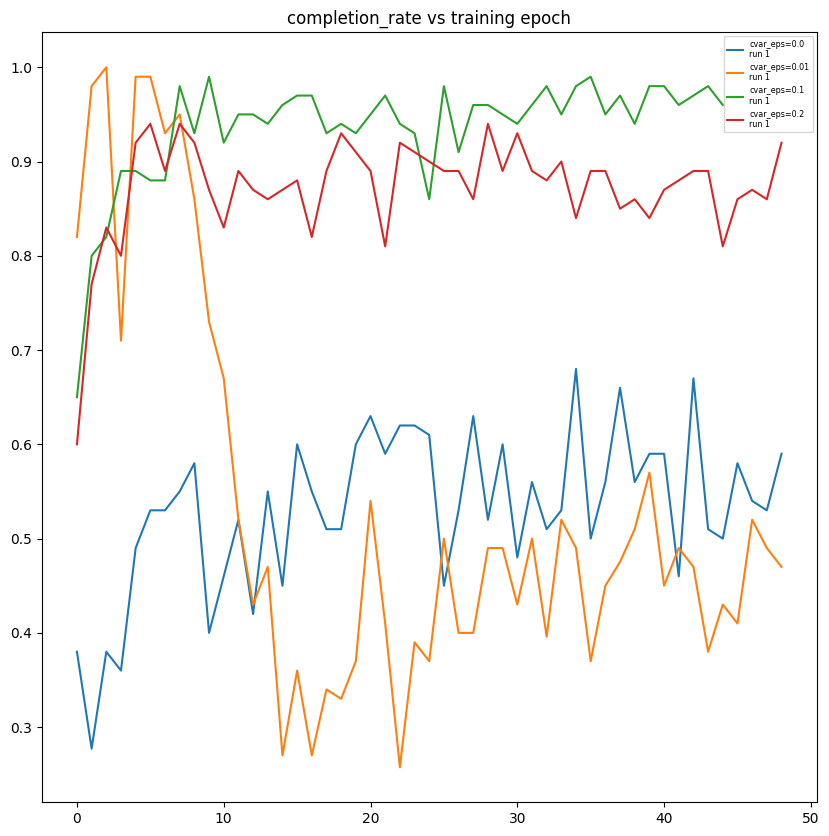

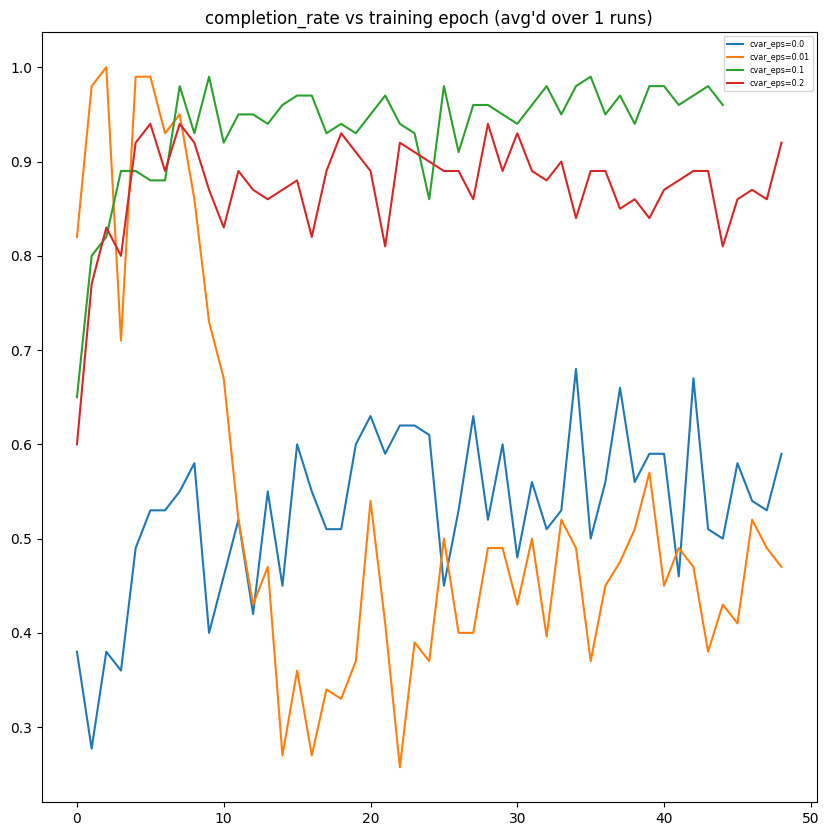

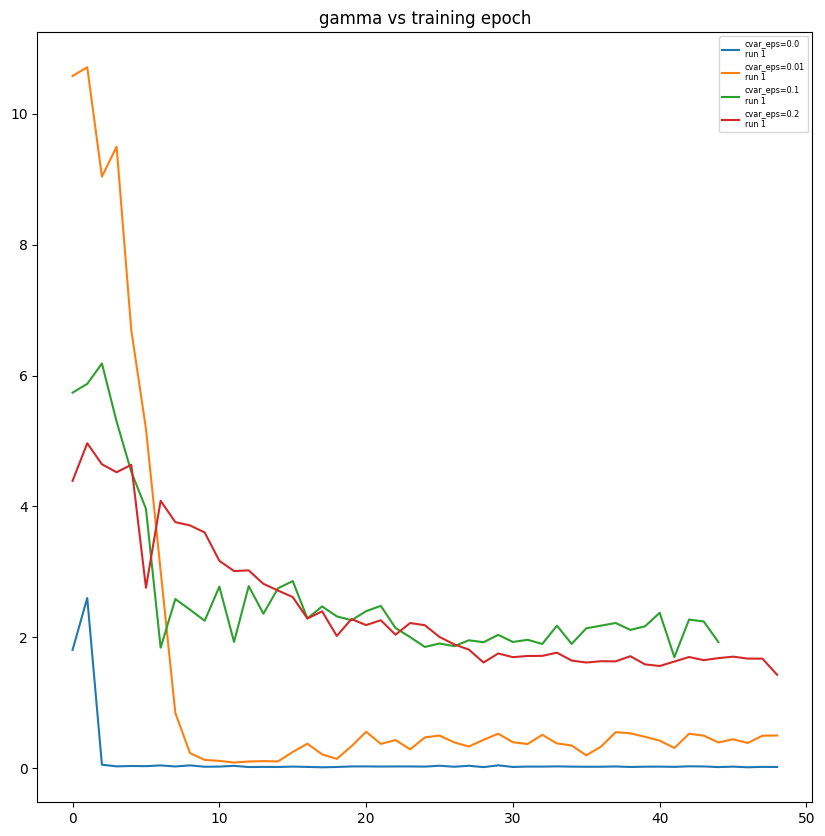

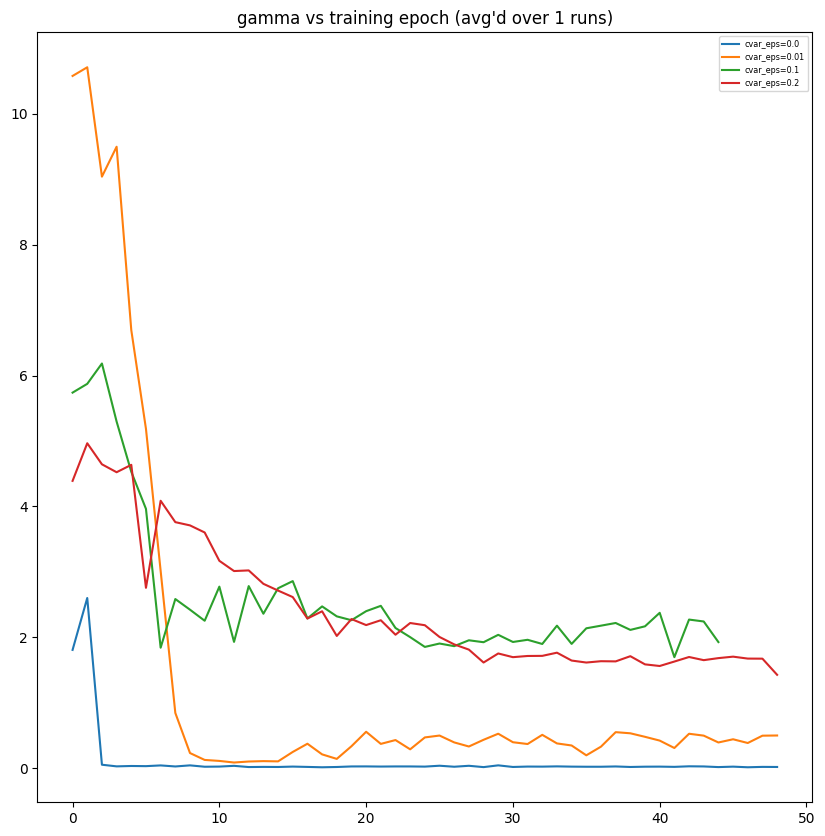

In [3]:
#######################
### Load Experiment ###
#######################

name = 'cvar'
exp = load_experiment(name)
plot_experiment_new(exp)

In [11]:
###############################
### Choose Model Checkpoint ###
###############################

config_idx = 1
run_idx = 0

#best_model_idx = np.argmax(exp['completion_rate'][config_idx][1][run_idx])
#best_model_idx = np.argmin(exp['gamma'][config_idx][1][run_idx])
best_model_idx = -1

ae = exp['ae_list'][config_idx][1][run_idx][best_model_idx]
fdyn = exp['fdyn_list'][config_idx][1][run_idx][best_model_idx]
ae.encode(torch.tensor([0.,0.,0.,0.]))

tensor([ 0.0001, -0.0003], device='cuda:0', grad_fn=<ViewBackward0>)

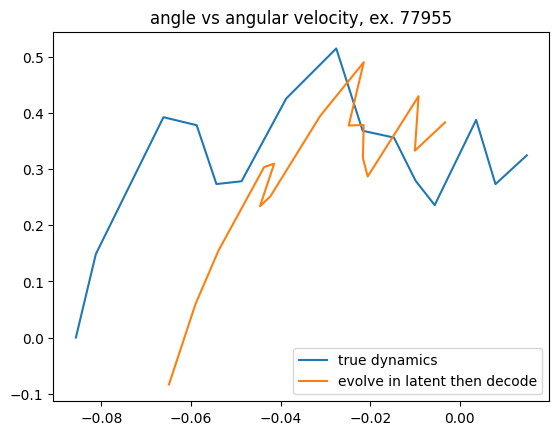

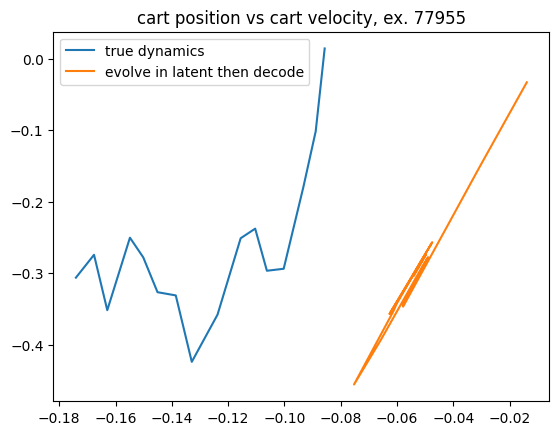

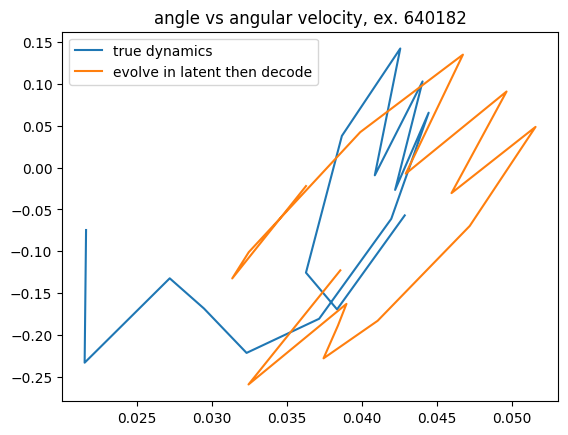

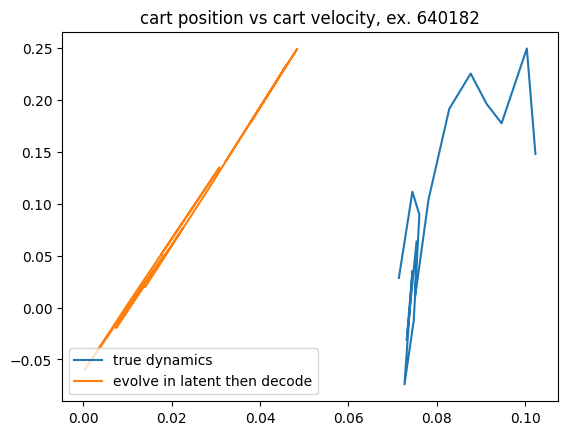

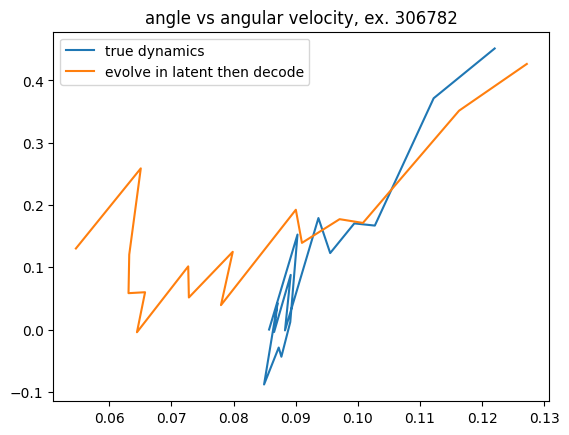

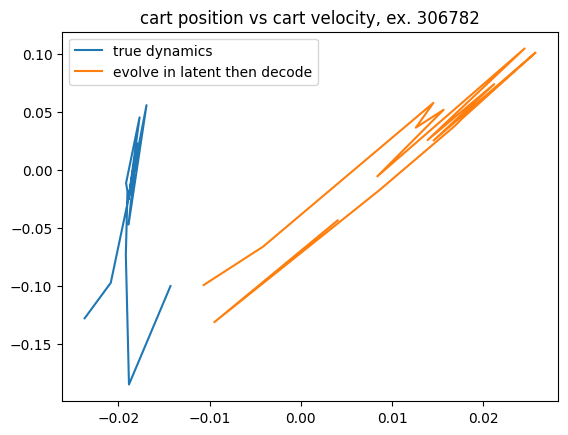

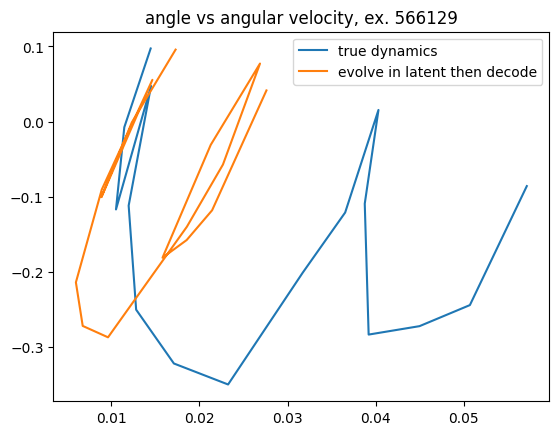

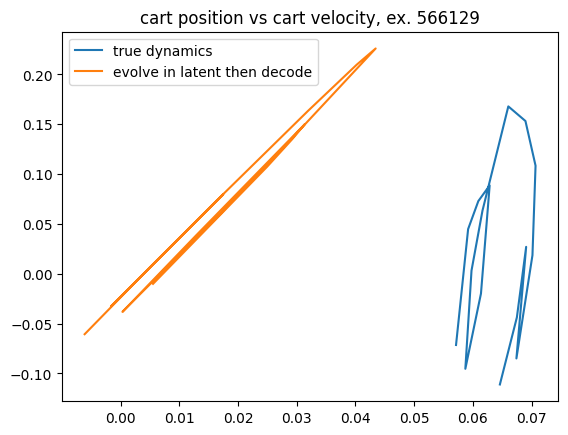

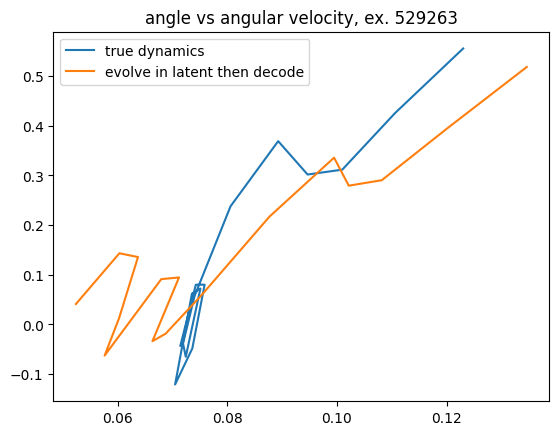

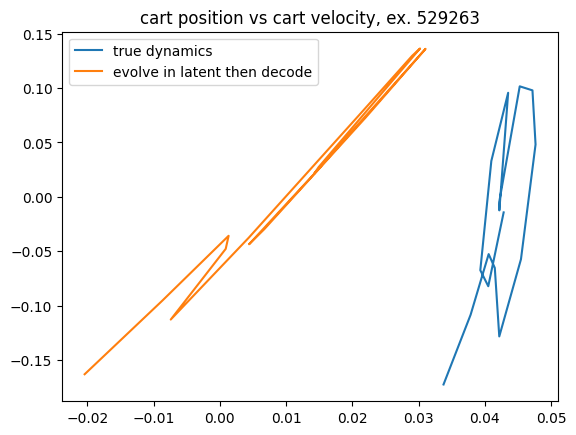

In [12]:
#######################################
### Plot Reconstructed Trajectories ###
#######################################

plot_trajectories(ae, fdyn, Xtest[0], Utest[0], 5, steps=params.traj_len)

z_eq tensor([[ 0.0001, -0.0003]], device='cuda:0', grad_fn=<AddmmBackward0>)


100%|██████████| 1000/1000 [01:25<00:00, 11.71it/s]


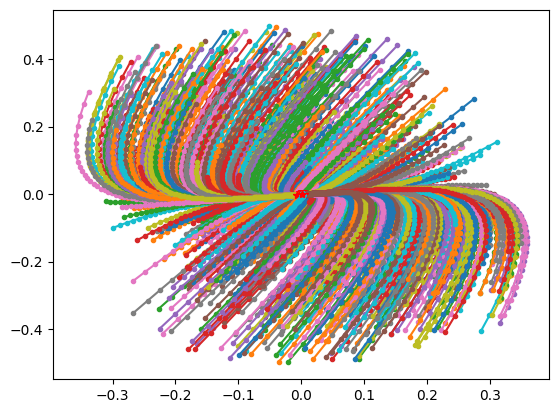

100%|██████████| 1000/1000 [01:12<00:00, 13.82it/s]


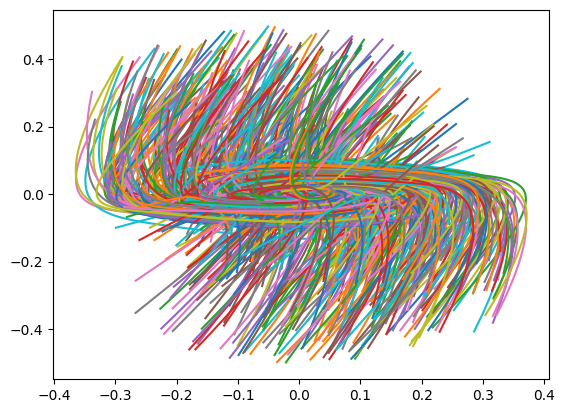

max x: 1.2426382899146986
max v: 0.7524785520314177
max theta: 0.21164023876190186
max w: 0.4997498393058777


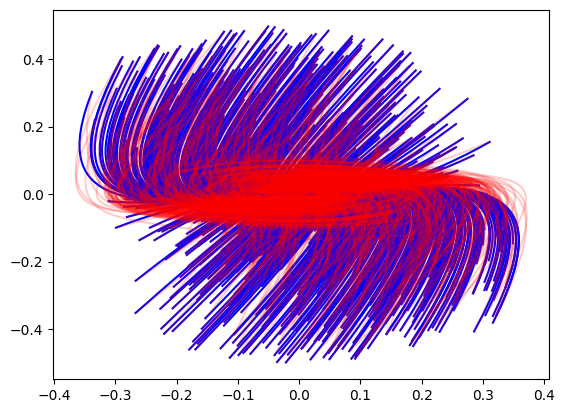

x data (1000, 151, 4)
z data (1000, 151, 2)
z proj data (1000, 151, 2)
u data (1000, 150, 1)
gamma forward 0.0155163035
gamma backward 1.2446817


In [14]:
####################################
### Initialize Data for Lyapunov ###
####################################

from plotting import plot_latent_trajectories
from utils import rollout_trajectories

r = 1.2e-1
r_test = r 
rz_init = 0.50#1.50 #2.25, 1.50 
n_traj = 1000#3000 
T = 150 #300
b = ae.encode(torch.tensor(4*[0.,])).cpu().detach().numpy()

for u_cost in [1]:
    lqr = LQR(ae, fdyn, u_cost=u_cost)
    pts, z_data, x_init_cond = plot_latent_trajectories(ae, fdyn, rz_init, n_traj, T=T, plot_quadratic=False, origin_spec=(b, r), lqr=lqr) #r=0.05
    x_data, z_proj_data, u_data, gammas = rollout_trajectories (ae, fdyn, lqr, x_init_cond, plot=True, n_traj=n_traj, T=T)
    gamma_fwd, gamma_bwd = gammas
    
    for zi in z_data:
        plt.plot(zi[:,0], zi[:,1], 'b-')
    for zi in z_proj_data:
        plt.plot(zi[:,0], zi[:,1], 'r-', alpha=0.2)
    plt.show()
    
    u_data = u_data[...,np.newaxis]
    
    print("x data", x_data.shape)
    print("z data", z_data.shape)
    print("z proj data", z_proj_data.shape)
    print("u data", u_data.shape)
    print("gamma forward", gamma_fwd)
    print("gamma backward", gamma_bwd) 

In [ ]:
###############################
### Learn Lyapunov Function ###
###############################

from controls import mlp_lyapunov_reparam
from theorem_tools import plot_violation

z_eq = ae.encode(torch.tensor([0.,0.,0.,0]).float())
print("z_eq:", z_eq)
rho = 0.80 #0.85 
features = 256
parameterization = "general" 
#V, rho, alpha, lip = mlp_lyapunov_reparam(z_data, epochs=int(4e4), lr=2e-4, grid_dens=100, rho=rho, z_eq=z_eq, parameterization=parameterization, features=256) #ep 0.5e4 #Baseline
V, rho, alpha, lip = mlp_lyapunov_reparam(z_data, epochs=int(1.1e4), lr=2e-4, grid_dens=100, rho=rho, z_eq=z_eq, parameterization=parameterization, features=256) #ep 0.5e4
plot_violation(V, rho, torch.tensor(z_data), ae, lip.item(), gamma_fwd, alpha/6, plot_contours=False)

z_eq: tensor([ 0.0001, -0.0003], device='cuda:0', grad_fn=<ViewBackward0>)
pd loss: False
dyn loss: True
lb loss False
grad loss False
rho: 0.8
c lb 0.1
l_dyn 1
l_pd 1
l_lb 1
l_grad 1e-06
using grid data, grid_density: 100
features: 256
coeff: 0.1
LyapunovGeneral(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=256, bias=False)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=False)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=1, bias=False)
  )
)
it 0: tensor([0.0102], device='cuda:0', grad_fn=<AddBackward0>)
it 1000: tensor([0.0013], device='cuda:0', grad_fn=<AddBackward0>)
it 2000: tensor([0.0011], device='cuda:0', grad_fn=<AddBackward0>)
it 3000: tensor([0.0011], device='cuda:0', grad_fn=<AddBackward0>)
it 4000: tensor([0.0010], device='cuda:0', grad_fn=<AddBackward0>)
it 5000: tensor([0.0010], device='cuda:0', grad_fn=<AddBackward0>)
it 6000: tensor([0.0009], device='cuda:0', grad_fn=<AddBackward0>)
it 7000: tensor([0.000

100%|██████████| 1539/1539 [04:34<00:00,  5.60it/s]


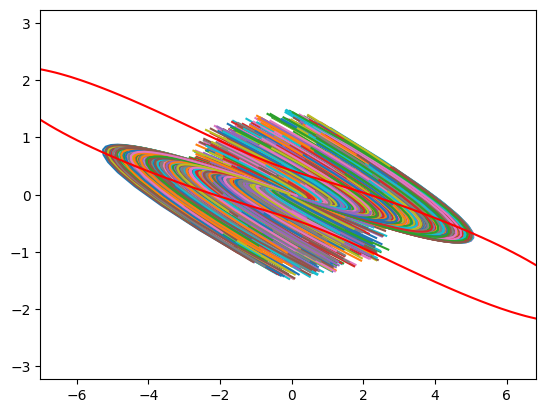

max x: 0.8471003568768312
max v: 0.9127859811286341
max theta: 0.37703365087509155
max w: 1.3544387873234416
(1539, 101, 4)


In [55]:
##############################################
### Compute Skeleton of Invariant Manifold ###
##############################################

from theorem_tools import compute_preimage, plot_lyapunov_lvlsets, verify_invariance

#manifold_initial_conditions = compute_preimage(ae, z_data, 0.50, 14, uniform_sampling=True) # BASELINE
manifold_initial_conditions = compute_preimage(ae, z_data, 0.50, 8, uniform_sampling=True)  # TEST, 1.33, 14
a0_manifold = torch.max(V(ae.encode(torch.tensor(manifold_initial_conditions)))).cpu().item() 

# n_traj doesn't do anything here, only the grid resolution in the previous step influences the number of trajecotries (one per each grid point)
manifold, _, _, _, _, _ = rollout_trajectories(ae, fdyn, lqr, manifold_initial_conditions, n_traj=500, T=100, V=V, a0=a0_manifold/6, n_per_axis=100)
print(manifold.shape)

In [56]:
############################################################
### Compute Preimage by Sampling from Invariant Manifold ###
############################################################

#Dx = compute_preimage(ae, z_data, 0.75, 7, uniform_sampling=True, X=manifold, n_samples=int(1e3), eps=0.01) # n_samples=4e4, eps=0.01 # BASELINE
Dx = compute_preimage(ae, z_data, 0.75, 7, uniform_sampling=True, X=manifold, n_samples=int(3e3), eps=0.01) # TEST

(2991, 4)


100%|██████████| 250/250 [02:38<00:00,  1.58it/s]


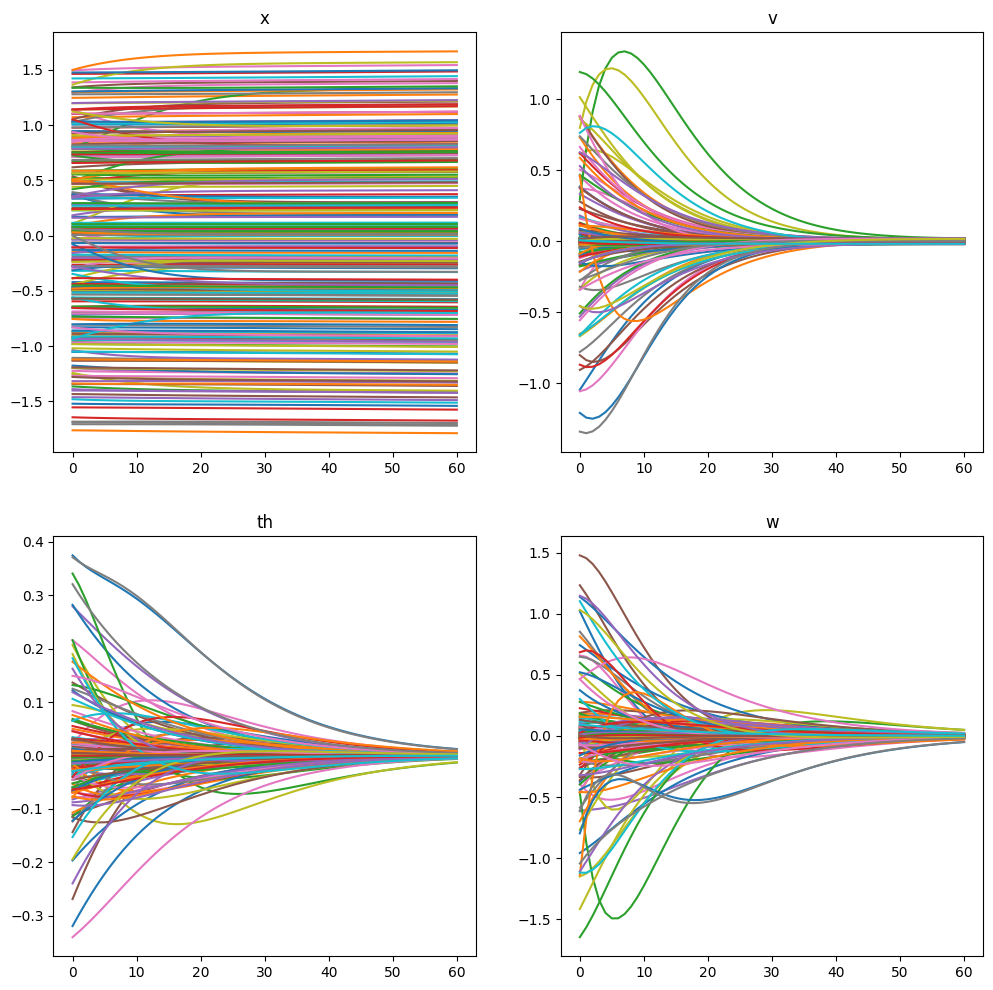

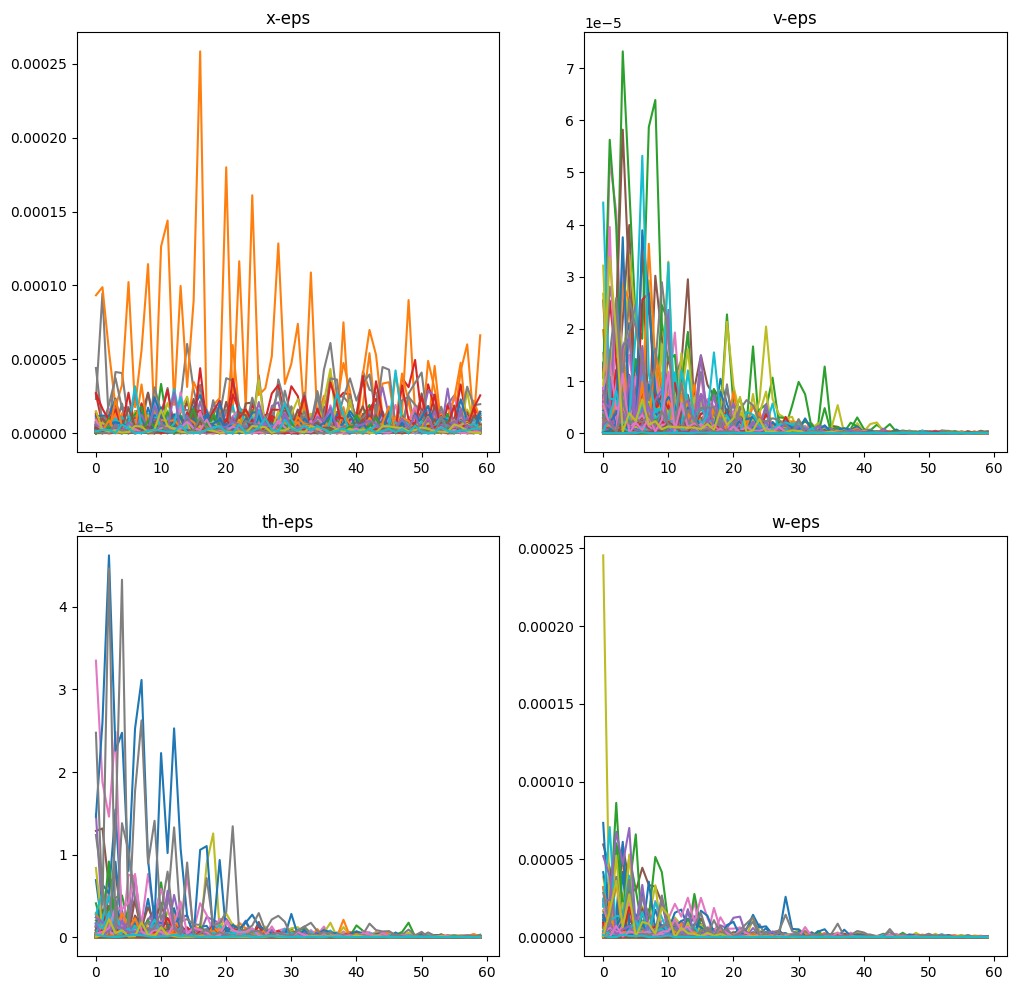

In [50]:
################################################
### Inspect Invariance of Invariant Manifold ###
################################################

print(Dx.shape)
_ = verify_invariance(ae, fdyn, T=60, stabilize=True, X0=Dx[0:250], manifold=manifold)

(2999, 4)
35.625247955322266
k_eval: [  2   3   4   5   6   7   8   9  10 200]


  0%|          | 0/2965 [00:00<?, ?it/s]/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/torch/utils/_device.py:104: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
100%|██████████| 2965/2965 [23:27<00:00,  2.11it/s]


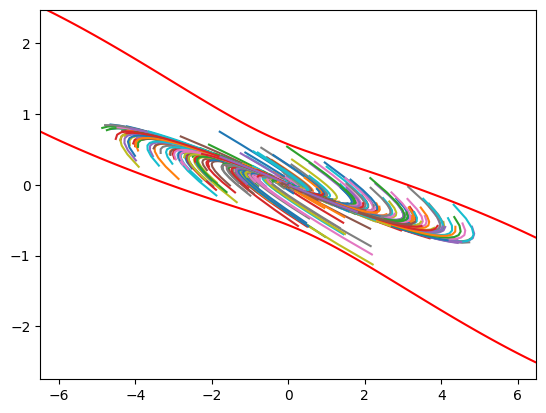

max x: 0.9151884072880148
max v: 0.8476585745811462
max theta: 0.2802428603172302
max w: 1.154308557510376
gamma fwd: 0.021661697
L: 31.86341667175293
a0: 11.875082651774088
rho: 0.85
Ly/(1-p): 4.6014376
R: 0.6273403167724609
k: [  2   3   4   5   6   7   8   9  10 200]
gamma_k forward: [0.03423054 0.05600621 0.0835011  0.10990272 0.1316621  0.14751518
 0.1574412  0.16202775 0.1621067  0.20491776]
Ly_k/(1-p^k): [3.93045786 4.62468218 5.5662453  6.2950019  6.73549168 6.91813203
 6.89560014 6.71898914 6.43146379 6.52937984]
xticks arg 1 [ 0  1  2  3  4  5  6  7  8  9 10]
mid [  2   3   4   5   6   7   8   9  10 200]
xticks arg 2 [1, np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(200)]


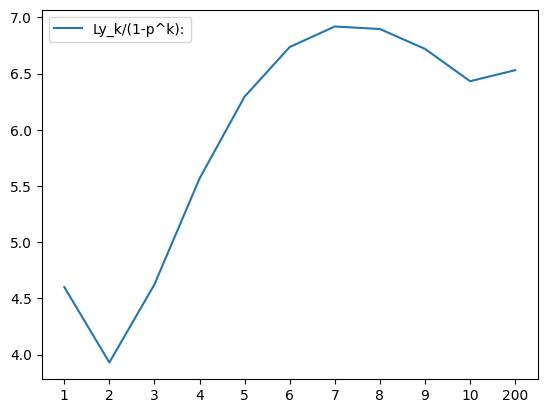

100%|██████████| 2999/2999 [17:53<00:00,  2.79it/s]


max x: 0.9151884072880148
max v: 0.9085343112138105
max theta: 0.3195091784000397
max w: 1.154308557510376


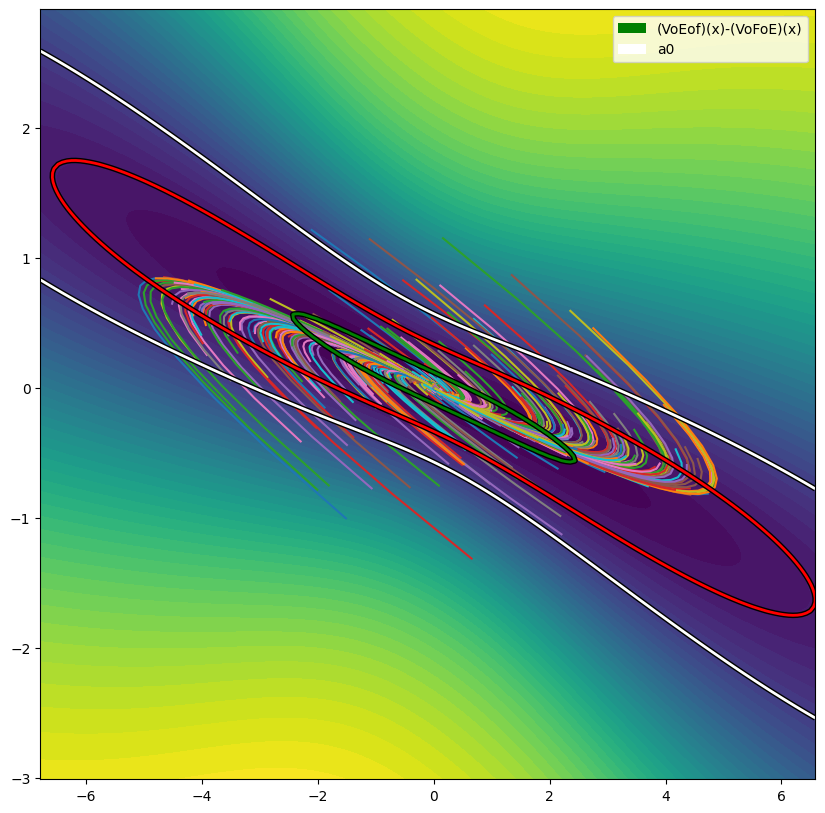

In [57]:
##################################################################
### Compute Ly/p and Levelsets over Trajectories from Preimage ###
##################################################################

a0 = torch.max(V(ae.encode(torch.tensor(Dx)))).cpu().item()
print(Dx.shape)
print(a0)
Dz = z_data
Dxtraj, gamma, L, res = plot_lyapunov_lvlsets(V, ae, fdyn, Dx, Dz, a0/3, rho, only_rollout=False, n_per_axis=175)

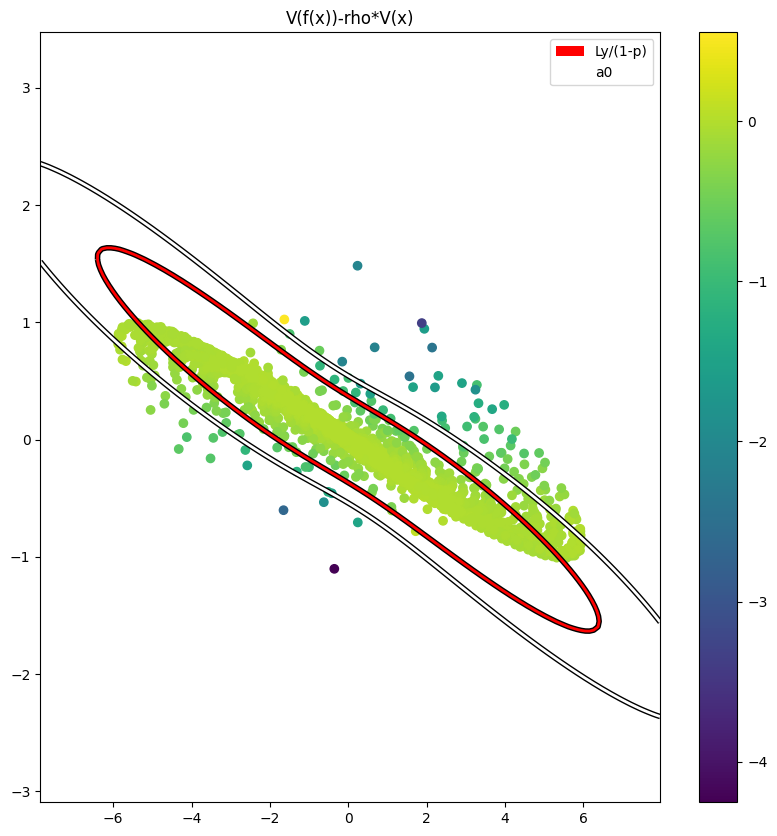

In [19]:
##################################################################
### Plot Violation of Lyapunov Condition for E(x) Trajectories ###
##################################################################

from theorem_tools import plot_violation, verify_invariance
plot_violation(V, rho, torch.tensor(Dxtraj), ae, gamma, L, a0/4)

100%|██████████| 4/4 [00:02<00:00,  1.51it/s]


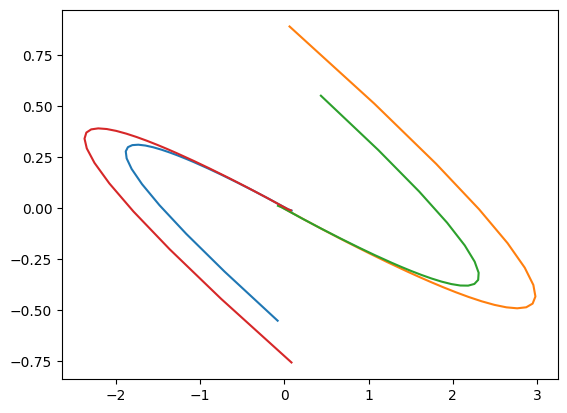

max x: 0.4118928613437243
max v: 0.5069957718938816
max theta: 0.15
max w: 0.622492811734929
x-theta traj: (4, 2001, 4)


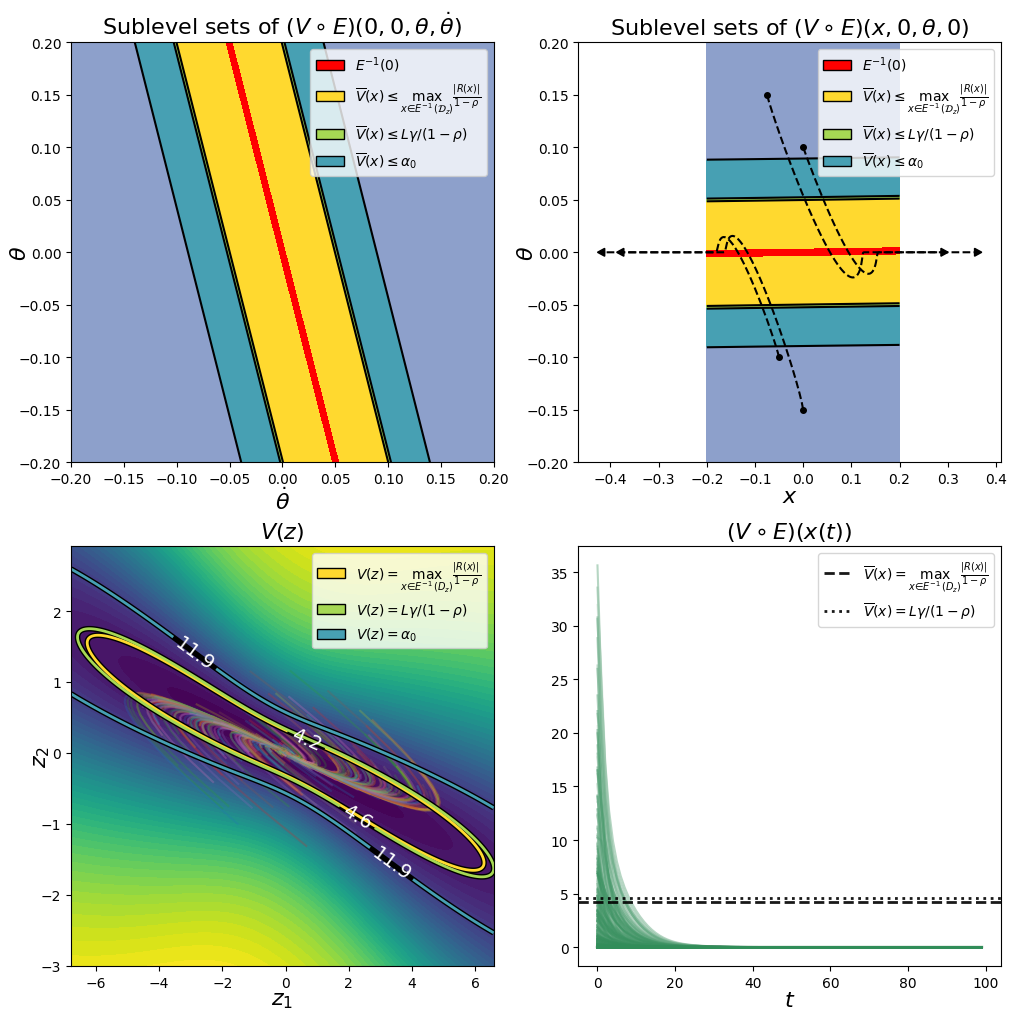

In [58]:
###################
### Make Figure ###
###################

from plotting import plot_lyapunov_slice
from theorem_tools import plot_figure_final
from utils import rollout_trajectories

lqr = LQR(ae, fdyn)

r_plot = 0.2 
X0_extra = np.array([[-0.05, 0.05, -0.1, 0.0],
                     [-0.075, -0.1, 0.15, 0.05],
                     [0.0, 0.0, 0.1, 0.0],
                     [0.0, 0.1, -0.15, 0.05]])
X_extra, _, _, _ = rollout_trajectories(ae, fdyn, lqr, X0_extra, T=2000)
plot_figure_final(V, ae, Dxtraj, 2*[r_plot], 2*[r_plot], res/(1-rho), a0/3, (L*gamma/(1-rho)).item(), n_per_axis=500, xth_traj=X_extra)